# Manuscript figures

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import seaborn as sns
import matplotlib.pyplot as plt
import pooch
import pandas as pd
from tqdm import tqdm

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Figure 1

### Figure 1A

![](img/fig1a.png)

### Figure 1B

Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [296]:
proteins_df = pg.merge_resources(rows_per_id=None)

haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "union",
                                         use_deepcopy = True) 

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/2503 [00:00<?, ?it/s]

Using deepcopy
Merging 2847 tx_ids using union


Merging haplotype datasets:   0%|          | 0/2 [00:00<?, ?it/s]

Merging haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Merged 132721 haplotypes across 2847 tx_ids.


Plot the number of haplotypes per protein, as well as the number of WT variants per haplotype.

Adding reference haplotype:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to dataframe:   0%|          | 0/2847 [00:00<?, ?it/s]

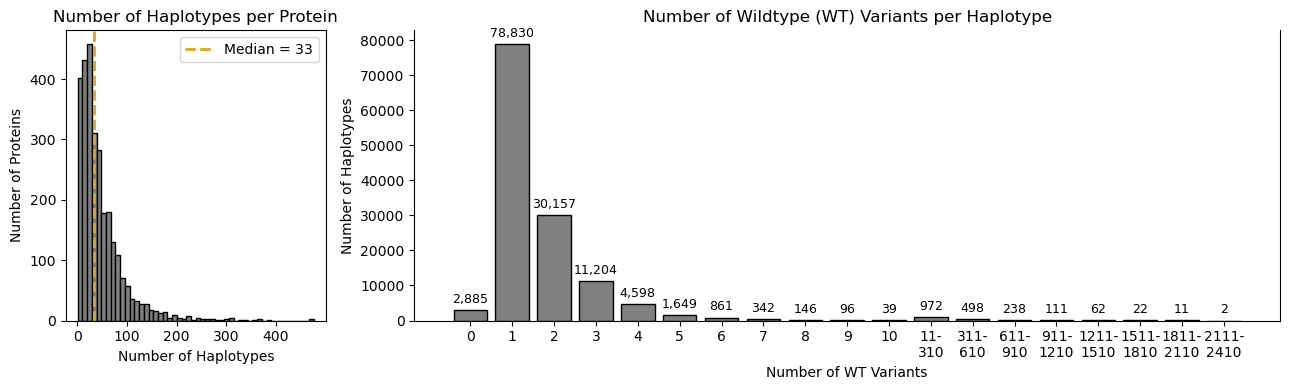

In [7]:
fig1b = hs.plot_haplotypes_summary(haplotypes)

### Figure 1C

Map haplotypes back to samples (individuals).

In [297]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 2847


Processing sample to haplotype name maps:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (19262867, 16)
>> haplotype(s): 132721
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2


,ENST_haplosaurus,cohort_sample,haplotype,cohort,sample,ploid_count,ploid,sex,Biosample ID,Population code,population_name,superpopulation,superpopulation_name,population,Data collections,population_code
0,ENST00000001146,GGVP:SC_GMJOL5309951,ENSP00000001146:264L>S,GGVP,SC_GMJOL5309951,2,0,male,NaN,GWJ,Gambian Jola,AFR,African Ancestry,GWJ,"Gambian Genome Variation Project (GRCh37),Gamb...",NaN
1,ENST00000001146,GGVP:SC_GMJOL5309951,ENSP00000001146:264L>S,GGVP,SC_GMJOL5309951,2,1,male,NaN,GWJ,Gambian Jola,AFR,African Ancestry,GWJ,"Gambian Genome Variation Project (GRCh37),Gamb...",NaN
2,ENST00000001146,1000GENOMES:phase_3:HG02151,ENSP00000001146:REF,1000GENOMES,HG02151,2,0,female,SAME1839403,CDX,Dai Chinese,EAS,East Asian Ancestry,CDX,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
3,ENST00000001146,1000GENOMES:phase_3:HG02151,ENSP00000001146:REF,1000GENOMES,HG02151,2,1,female,SAME1839403,CDX,Dai Chinese,EAS,East Asian Ancestry,CDX,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
4,ENST00000001146,GGVP:SC_GMWOF5428867,ENSP00000001146:REF,GGVP,SC_GMWOF5428867,2,0,female,NaN,GWW,Gambian Wolof,AFR,African Ancestry,GWW,"Gambian Genome Variation Project (GRCh37),Gamb...",NaN


In [298]:
freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
) 
freq_df.head()

0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    35540
EAS    22458
EUR    14917
SAS    13574
AMR     9224
CSA     5134
MID     4439
OCE     1850
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 80.72%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000001146:110H>Y,1.712292e-07,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,1.712292e-07,1,AFR,1.0
1,"ENSP00000001146:119R>H,264L>S",2.054751e-06,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,2.054751e-06,1,AFR,12.0
2,ENSP00000001146:123M>V,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MID,1.240141e-06,1,MID,1.0
3,"ENSP00000001146:140N>I,380E>K",0.000000e+00,0.0,0.0,2.738582e-07,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,EAS,2.738582e-07,1,EAS,1.0
4,ENSP00000001146:143K>R,1.712292e-07,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,1.712292e-07,1,AFR,1.0


Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

0 samples are missing superpopulation metadata


/home/schilder/projects/VEP_protein/src/haplosaurus.py:3279: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples = get_haplotype_samples(haplotypes, unnest=True, remove_prefix=True)


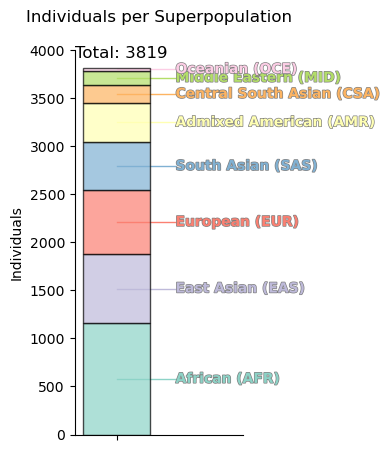

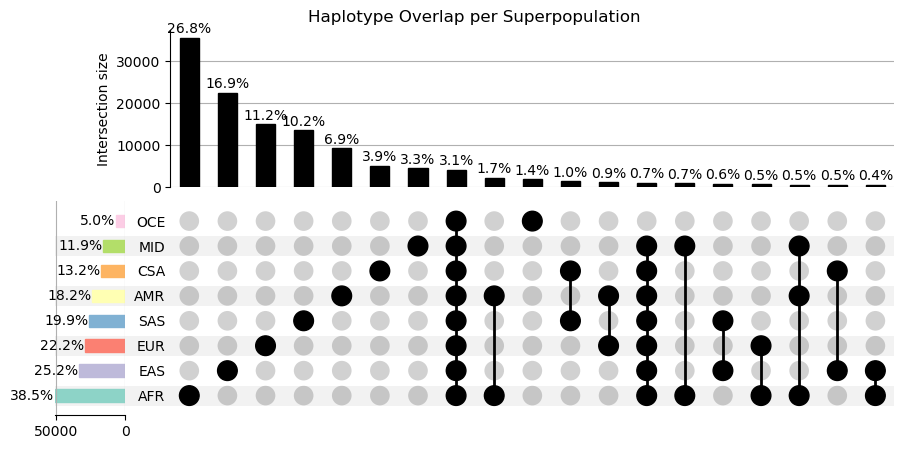

In [10]:
fig1c = hs.plot_haplotypes_and_superpop_bar(freq_df,
                                            haplotypes,
                                            width_ratios=(.2,1), figsize=(13,5))

### Fig 1D

In [ ]:
vep_files = va.list_vep_files(as_df=True)

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 877132 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 8
scoring_strategy: 3
variant_set: 1
haplotype: 111422
protein: 2251


In [ ]:
# Focus on one model for the main plots
model_name = "esm3_sm_open_v1"

vep_df = va.merge_vep(add_metadata=True, 
                      scoring_strategy=["masked-marginals"], 
                      vep_files=vep_files.loc[vep_files['model_location']==model_name]
                           )
vep_df.head() 



No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 17353 masked-marginals parquet files


Reading files:   0%|          | 0/17353 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 4.72GB/s]


VEP dataframe shape: (541747, 72)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000368190:REF,NP_004637.1,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,V1241A,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,Benign,-0.218262,masked-marginals,True,esm3_sm_open_v1,clinical_ProteinGym_substitutions,ENSP00000368190,ENST00000378910,False,19,35826518,2139884,A,G,.,PASS,2139884,19:35826518,G,4868,NM_004646.4,Transcript,missense_variant,4389,3722,1241,V/A,gTg/gCg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_004646.4:c.3722T>C,NP_004637.1:p.Val1241Ala,-,NaN,NaN,1868717,MedGen:CN517202,not_provided,NC_000019.10:g.35826518A>G,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,NPHS1:4868,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.152563,0.000203,7,likely_benign
1,ENSP00000368190:REF,NP_004637.1,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,E1235K,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,Benign,-0.796387,masked-marginals,True,esm3_sm_open_v1,clinical_ProteinGym_substitutions,ENSP00000368190,ENST00000378910,False,19,35826537,1541443,C,T,.,PASS,1541443,19:35826537,T,4868,NM_004646.4,Transcript,missense_variant,4370,3703,1235,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_004646.4:c.3703G>A,NP_004637.1:p.Glu1235Lys,-,NaN,NaN,1631326,MedGen:CN517202,not_provided,NC_000019.10:g.35826537C>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,NPHS1:4868,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.611542,-0.001346,7,likely_benign
2,ENSP00000368190:REF,NP_004637.1,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,Y1217D,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,Benign,-2.707031,masked-marginals,True,esm3_sm_open_v1,clinical_ProteinGym_substitutions,ENSP00000368190,ENST00000378910,False,19,35826591,762830,A,C,.,PASS,762830,19:35826591,C,4868,NM_004646.4,Transcript,missense_variant,4316,3649,1217,Y/D,Tat/Gat,-,MODERATE,-,-1,-,-,-,A,A,-,NM_004646.4:c.3649T>G,NP_004637.1:p.Tyr1217Asp,-,NaN,0.00017,772597,MedGen:CN517202,not_provided,NC_000019.10:g.35826591A>C,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,NPHS1:4868,SO:0001583|missense_variant,1,114879227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.610264,-0.000569,7,likely_benign
3,ENSP00000368190:REF,NP_004637.1,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,P1185L,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,Benign,-1.189453,masked-marginals,True,esm3_sm_open_v1,clinical_ProteinGym_substitutions,ENSP00000368190,ENST00000378910,False,19,35830884,2079186,G,A,.,PASS,2079186,19:35830884,A,4868,NM_004646.4,Transcript,missense_variant,4221,3554,1185,P/L,cCg/cTg,-,MODERATE,-,-1,-,-,-,G,G,-,NM_004646.4:c.3554C>T,NP_004637.1:p.Pro1185Leu,-,NaN,NaN,2131952,MedGen:CN517202,not_provided,NC_000019.10:g.35830884G>A,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,NPHS1:4868,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.627251,-0.000875,7,likely_benign
4,ENSP00000368190:REF,NP_004637.1,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,R1140S,MALGTTLRASLLLLGLLTEGLAQLAIPASVPRGFWALPENLTVVEG...,Benign,0.955078,masked-marginals,True,esm3_sm_open_v1,clinical_ProteinGym_substitutions,ENSP00000368190,ENST00000378910,False,19,35831116,259498,G,T,.,PASS,259498,19:35831116,T,48

In [ ]:


pg_subs_paths = pooch.retrieve("https://marks.hms.harvard.edu/proteingym/ProteinGym_v1.1/clinical_ProteinGym_substitutions.zip",
                known_hash=None,
                processor=pooch.Unzip(),
                progressbar=True)

pg_subs = pd.concat([pd.read_csv(path, index_col=0) for path in tqdm(pg_subs_paths)])
sub_counts = pg_subs.groupby("DMS_bin_score").size().reset_index().rename(columns={"DMS_bin_score":"ClinSig", 0: "Count"})
sub_counts["Source"] = "ProteinGym"
sub_counts["Consequence"] = "Missense"
sub_counts


100%|██████████| 2525/2525 [00:02<00:00, 1094.32it/s]


,ClinSig,Count,Source,Consequence
0,Benign,30727,ProteinGym,Missense
1,Pathogenic,32000,ProteinGym,Missense


In [502]:
# SpliceVarDB: splicing
splice_variants = pd.read_csv("~/projects/VEP_DNA/data/splicing/splicevardb_x_clinvar_snv.csv")

splice_counts = splice_variants.groupby("CLNSIG_simplified").size().reset_index().rename(columns={"CLNSIG_simplified":"ClinSig", 0: "Count"})
splice_counts["Source"] = "SpliceVarDB"
splice_counts["Consequence"] = "Splicing"
splice_counts


,ClinSig,Count,Source,Consequence
0,benign,2615,SpliceVarDB,Splicing
1,pathogenic,3327,SpliceVarDB,Splicing
2,vus,2548,SpliceVarDB,Splicing


In [ ]:
import src.clinvar as cv
 
# ClinVar: UTR
utr_variants = cv.read_bed("~/projects/VEP_DNA/data/UTR/clinvar_utr_snv.bed.gz").to_pandas()

clnsig_map = {"likely_path": "pathogenic",
                          "likely_pathogenic": "pathogenic",
                          "pathogenic": "pathogenic",
                          "path": "pathogenic",
                          "likely_benign": "benign"}
utr_counts = utr_variants.replace({"CLNSIG_simple": clnsig_map}).groupby("CLNSIG_simple").size().reset_index().rename(columns={"CLNSIG_simple":"ClinSig", 0: "Count"})

utr_counts["Source"] = "ClinVar"
utr_counts["Consequence"] = "UTR"
utr_counts

Extracting ID columns.
Using default maps.
Simplifying annotations.


,ClinSig,Count,Source,Consequence
0,benign,11718,ClinVar,UTR
1,pathogenic,2053,ClinVar,UTR


      ClinSig  Count       Source Consequence    Consequence (Source)
0      benign   2615  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
1  pathogenic   3327  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
0      benign  11718      ClinVar         UTR           UTR (ClinVar)
1  pathogenic   2053      ClinVar         UTR           UTR (ClinVar)
0      benign  30727   ProteinGym    Missense   Missense (ProteinGym)
1  pathogenic  32000   ProteinGym    Missense   Missense (ProteinGym)


Text(0, 0.5, 'Consequence (Source)')

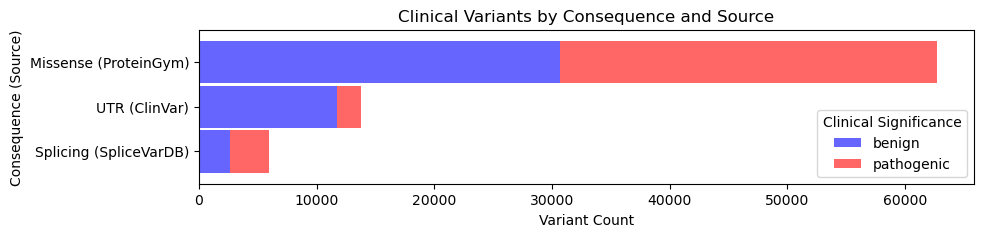

In [537]:

palette = utils.get_clinsig_palette()
variant_counts = pd.concat([splice_counts, utr_counts, sub_counts]) 
variant_counts["ClinSig"] = variant_counts["ClinSig"].str.lower()
variant_counts = variant_counts.loc[variant_counts["ClinSig"].str.lower()!="vus"] 
variant_counts["Consequence (Source)"] = variant_counts["Consequence"] + " (" + variant_counts["Source"] + ")"
print(variant_counts)
# Create figure and axes with specified size
fig, ax = plt.subplots(figsize=(10, 2))

# Group data by Consequence (Source) and ClinSig
grouped = variant_counts.groupby(['Consequence (Source)', 'ClinSig'], sort=False)['Count'].sum().unstack()

# Create stacked bar plot
grouped.plot(kind='barh', 
            stacked=True,
            color=[palette["benign"], palette["path"]],  # Benign, Pathogenic 
            width=0.95,
            ax=ax)  # Specify the axes to plot on
plt.title("Clinical Variants by Consequence and Source")
plt.legend(title="Clinical Significance")
plt.xlabel('Variant Count')
plt.ylabel('Consequence (Source)')


### Fig 1E

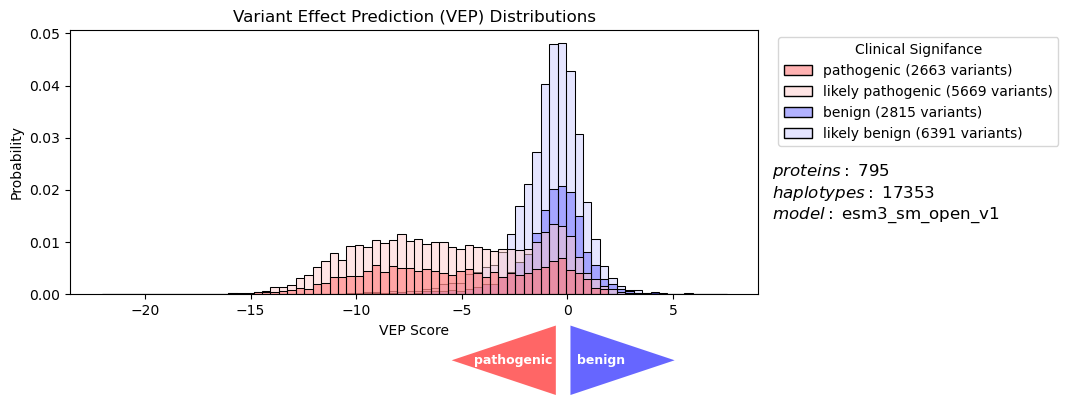

In [539]:
fig1e = va.plot_vep_histogram_with_arrows(vep_df, model_name=model_name,  
                                          arrow_head_length=0.047,
                                          arrow_length=.19,
                                          figsize=(11, 4),
                                          x_label="VEP Score", 
                                          title="Variant Effect Prediction (VEP) Distributions",
                                          arrow_text_fontsize=9,
                                          external_legend_annotation=True)

### Fig 1F

In [130]:
#### Violin plot version ####
# fig1f = va.plot_vep_percentiles(vep_df, row=None, col=None, height=5, aspect=1.5, x_rotation=0, x_ha='center')

<string>:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


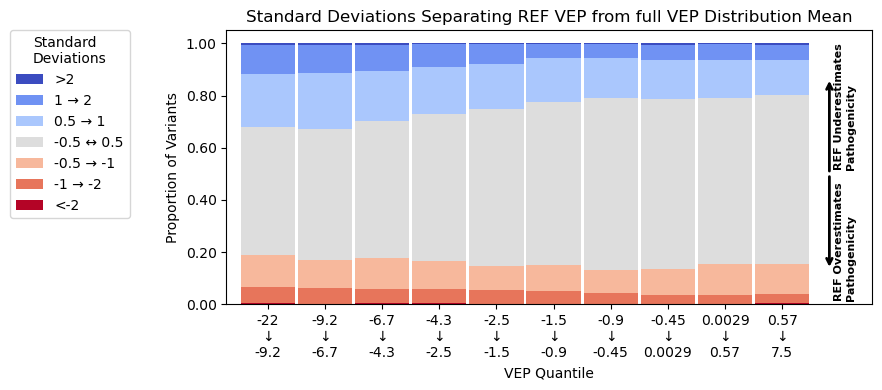

In [19]:
#### Standard Deviation version ####
fig1f = va.plot_ref_vep_std_stacked_bar(vep_df)

<string>:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


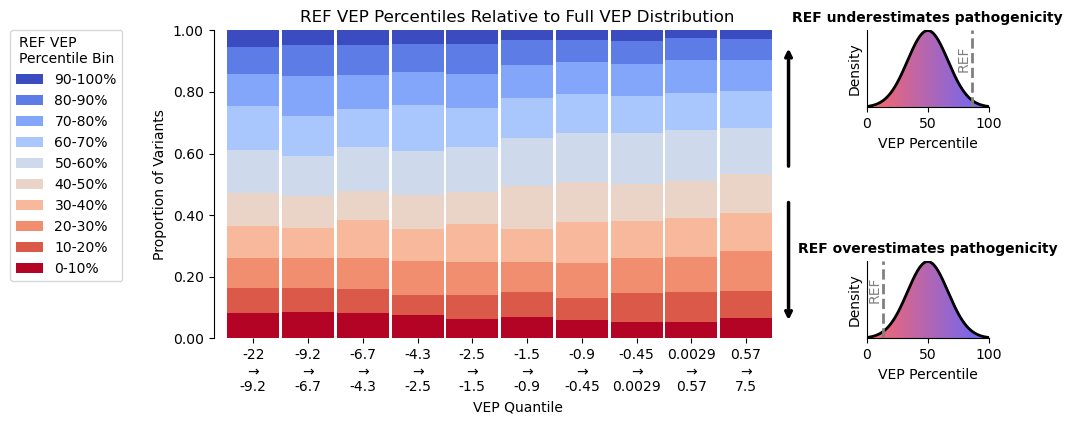

In [135]:
#### Percentile barplot version ####
fig1f = va.plot_ref_vep_percentile_stacked_bar(vep_df,figsize=(10, 4), 
                                               barplot_width_ratio=5,
                                                   schematic_width_ratio=1,
                                                   schematic_padding=0.125,
                                               schematic_heights=[0.25, 0.50, 0.25])

In [169]:
# For each group, get the "VEP" value for the row where is_ref==True
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
ref_vep = vep_df.loc[vep_df["is_ref"]].set_index(groupby_cols)["VEP"]
vep_df["VEP_REF"] = vep_df.set_index(groupby_cols).index.map(ref_vep)
vep_df["VEP_ref_diff"] = vep_df["VEP_REF"] - vep_df["VEP"]

In [ ]:
## Supplementary Figures

In [265]:
vep_df = va.compute_representativeness_stats(vep_df, is_ref=False)

In [278]:
vep_df["n_haplotypes"] = vep_df.groupby(["model_location", "scoring_strategy", "mutant"])["haplotype"].transform("nunique")

Sampling 6 rows from 5
                                  mutant  protein
model_location  scoring_strategy                 
esm3_sm_open_v1 masked-marginals       5        4


<string>:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


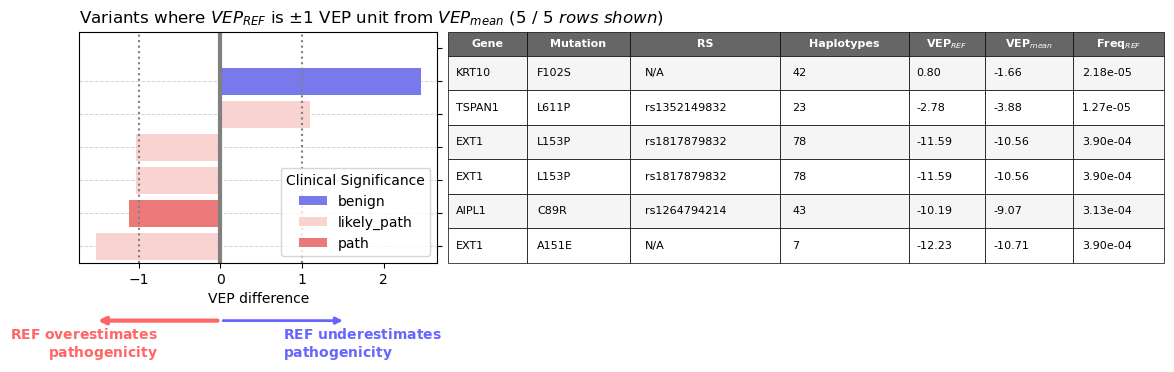

(<Axes: title={'left': 'Variants where $\\it{VEP_{REF}}$ is $\\pm$1 VEP unit from $\\it{VEP_{mean}}$$\\it{\\ (5\\ /\\ 5\\ rows\\ shown)}$'}, xlabel='VEP difference'>,
 <Axes: >)

In [458]:
va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_mean_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{mean}}$",
                          max_rows=6,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.25,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=True)

Sampling 6 rows from 695
                                  mutant  protein
model_location  scoring_strategy                 
esm3_sm_open_v1 masked-marginals       6        5


<string>:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


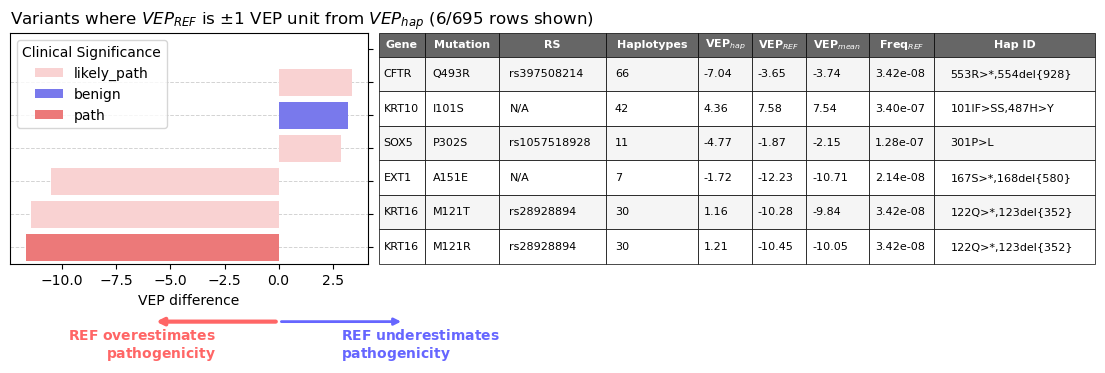

(<Axes: title={'left': 'Variants where $\\it{VEP_{REF}}$ is $\\pm$1 VEP unit from $\\it{VEP_{hap}}$ (6/695 rows shown)'}, xlabel='VEP difference'>,
 <Axes: >)

In [452]:
va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_ref_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{hap}}$",
                          max_rows=6,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.25,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=None)

In [460]:
import matplotlib.pyplot as plt

# Create bins: '<-1', '-1 to 1', '>1'
bins = pd.cut(
    vep_df.loc[~vep_df["is_ref"], "VEP_ref_diff"],
    bins=[-float('inf'), -1, 1, float('inf')],
    labels=['<-1', '-1 to 1', '>1']
)
bin_counts = bins.value_counts().sort_index()
bin_counts
 

VEP_ref_diff
<-1           520
-1 to 1    521287
>1            180
Name: count, dtype: int64